In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns

In [3]:
weather_path = kagglehub.dataset_download("selfishgene/historical-hourly-weather-data")
wildfire_path = kagglehub.dataset_download("rtatman/188-million-us-wildfires")

print("Weather Data Path:", weather_path)
print("Wildfire Data Path:", wildfire_path)


Weather Data Path: /Users/gaoyiming/.cache/kagglehub/datasets/selfishgene/historical-hourly-weather-data/versions/2
Wildfire Data Path: /Users/gaoyiming/.cache/kagglehub/datasets/rtatman/188-million-us-wildfires/versions/2


In [4]:
import os

# List all files in the wildfire and weather dataset directories
wildfire_files = os.listdir(wildfire_path)
weather_files = os.listdir(weather_path)

print("Wildfire Dataset Files:", wildfire_files)
print("Weather Dataset Files:", weather_files)


Wildfire Dataset Files: ['FPA_FOD_20170508.sqlite']
Weather Dataset Files: ['weather_description.csv', 'humidity.csv', 'wind_direction.csv', 'temperature.csv', 'pressure.csv', 'city_attributes.csv', 'wind_speed.csv']


In [5]:
city_attributes_df = pd.read_csv(os.path.join(weather_path, 'city_attributes.csv'))
#print(city_attributes_df.shape)
print(city_attributes_df.head())
#print(len(city_attributes_df['City'].unique()))

            City        Country   Latitude   Longitude
0      Vancouver         Canada  49.249660 -123.119339
1       Portland  United States  45.523449 -122.676208
2  San Francisco  United States  37.774929 -122.419418
3        Seattle  United States  47.606209 -122.332069
4    Los Angeles  United States  34.052231 -118.243683


In [6]:
weather_description_df = pd.read_csv(os.path.join(weather_path, 'weather_description.csv'))
weather_description_df = weather_description_df[1:]
print(weather_description_df.columns)

Index(['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle',
       'Los Angeles', 'San Diego', 'Las Vegas', 'Phoenix', 'Albuquerque',
       'Denver', 'San Antonio', 'Dallas', 'Houston', 'Kansas City',
       'Minneapolis', 'Saint Louis', 'Chicago', 'Nashville', 'Indianapolis',
       'Atlanta', 'Detroit', 'Jacksonville', 'Charlotte', 'Miami',
       'Pittsburgh', 'Toronto', 'Philadelphia', 'New York', 'Montreal',
       'Boston', 'Beersheba', 'Tel Aviv District', 'Eilat', 'Haifa',
       'Nahariyya', 'Jerusalem'],
      dtype='object')


In [7]:
# Load a specific weather file (e.g., temperature.csv)
temperature_df = pd.read_csv(os.path.join(weather_path, 'temperature.csv'))
temperature_df = temperature_df[1:]
print(temperature_df['datetime'].unique())

['2012-10-01 13:00:00' '2012-10-01 14:00:00' '2012-10-01 15:00:00' ...
 '2017-11-29 22:00:00' '2017-11-29 23:00:00' '2017-11-30 00:00:00']


In [8]:
# Load a specific weather file (e.g., temperature.csv)
humidity_df = pd.read_csv(os.path.join(weather_path, 'humidity.csv'))
humidity_df = humidity_df[1:]
print(humidity_df.head())
print(humidity_df.shape)

              datetime  Vancouver  Portland  San Francisco  Seattle  \
1  2012-10-01 13:00:00       76.0      81.0           88.0     81.0   
2  2012-10-01 14:00:00       76.0      80.0           87.0     80.0   
3  2012-10-01 15:00:00       76.0      80.0           86.0     80.0   
4  2012-10-01 16:00:00       77.0      80.0           85.0     79.0   
5  2012-10-01 17:00:00       78.0      79.0           84.0     79.0   

   Los Angeles  San Diego  Las Vegas  Phoenix  Albuquerque  ...  Philadelphia  \
1         88.0       82.0       22.0     23.0         50.0  ...          71.0   
2         88.0       81.0       21.0     23.0         49.0  ...          70.0   
3         88.0       81.0       21.0     23.0         49.0  ...          70.0   
4         88.0       81.0       21.0     23.0         49.0  ...          69.0   
5         88.0       80.0       21.0     24.0         49.0  ...          69.0   

   New York  Montreal  Boston  Beersheba  Tel Aviv District  Eilat  Haifa  \
1      58

In [9]:
# Load a specific weather file (e.g., temperature.csv)
wind_direction_df = pd.read_csv(os.path.join(weather_path, 'wind_direction.csv'))
wind_direction_df = wind_direction_df[1:]
wind_direction_df.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
1,2012-10-01 13:00:00,0.0,0.0,150.0,0.0,0.0,0.0,0.0,10.0,360.0,...,270.0,260.0,230.0,60.0,135.0,101.0,30.0,336.0,336.0,329.0
2,2012-10-01 14:00:00,6.0,4.0,147.0,2.0,0.0,0.0,8.0,9.0,360.0,...,270.0,260.0,230.0,60.0,157.0,315.0,30.0,336.0,336.0,329.0
3,2012-10-01 15:00:00,20.0,18.0,141.0,10.0,0.0,0.0,23.0,9.0,360.0,...,271.0,260.0,231.0,60.0,157.0,307.0,30.0,336.0,336.0,329.0
4,2012-10-01 16:00:00,34.0,31.0,135.0,17.0,0.0,0.0,37.0,9.0,360.0,...,272.0,260.0,233.0,60.0,157.0,294.0,30.0,336.0,336.0,329.0
5,2012-10-01 17:00:00,47.0,44.0,129.0,24.0,0.0,0.0,51.0,8.0,360.0,...,274.0,261.0,234.0,61.0,157.0,282.0,30.0,336.0,336.0,329.0


In [10]:
pressure_df = pd.read_csv(os.path.join(weather_path, 'pressure.csv'))
pressure_df = pressure_df[1:]

wind_speed_df = pd.read_csv(os.path.join(weather_path, 'wind_speed.csv'))
wind_speed_df = wind_speed_df[1:]

In [11]:
for df in [humidity_df, wind_direction_df, temperature_df, pressure_df, wind_speed_df]:
    df.rename(columns={'datetime': 'Datetime'}, inplace=True)  # Ensure same column name
    df['Datetime'] = pd.to_datetime(df['Datetime'])

# Function to reshape the data
def reshape_df(df, variable_name):
    return df.melt(id_vars=['Datetime'], var_name='City', value_name=variable_name)

# Reshape each DataFrame
humidity_melted = reshape_df(humidity_df, 'Humidity')
wind_direction_melted = reshape_df(wind_direction_df, 'Wind_Direction')
temperature_melted = reshape_df(temperature_df, 'Temperature')
pressure_melted = reshape_df(pressure_df, 'Pressure')
wind_speed_melted = reshape_df(wind_speed_df, 'Wind_Speed')
#print(wind_speed_melted)

# Merge all DataFrames on 'Datetime' and 'City'
weather_df = humidity_melted.merge(wind_direction_melted, on=['Datetime', 'City']) \
                           .merge(temperature_melted, on=['Datetime', 'City']) \
                           .merge(pressure_melted, on=['Datetime', 'City']) \
                           .merge(wind_speed_melted, on=['Datetime', 'City'])
print(weather_df['City'].value_counts())
print(weather_df['Wind_Speed'].value_counts())

# Drop 'Datetime' and compute correlation
#correlation_matrix = weather_df.drop(columns=['Datetime']).corr()
#print(correlation_matrix)

'''

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Weather Parameters")
plt.show()
'''

Vancouver            45252
Portland             45252
Detroit              45252
Jacksonville         45252
Charlotte            45252
Miami                45252
Pittsburgh           45252
Toronto              45252
Philadelphia         45252
New York             45252
Montreal             45252
Boston               45252
Beersheba            45252
Tel Aviv District    45252
Eilat                45252
Haifa                45252
Nahariyya            45252
Atlanta              45252
Indianapolis         45252
Nashville            45252
Albuquerque          45252
San Francisco        45252
Seattle              45252
Los Angeles          45252
San Diego            45252
Las Vegas            45252
Phoenix              45252
Denver               45252
Chicago              45252
San Antonio          45252
Dallas               45252
Houston              45252
Kansas City          45252
Minneapolis          45252
Saint Louis          45252
Jerusalem            45252
Name: City, dtype: int64
1.0

'\n\n# Plot the heatmap\nplt.figure(figsize=(10, 6))\nsns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)\nplt.title("Correlation Heatmap of Weather Parameters")\nplt.show()\n'

In [12]:
import sqlite3
import pandas as pd
import os

wildfire_db_path = os.path.join(wildfire_path, 'FPA_FOD_20170508.sqlite')
conn = sqlite3.connect(wildfire_db_path)

fire_data = pd.read_sql("SELECT * FROM Fires", conn)
# Close the connection when done
conn.close()
print(fire_data.head())

# List all tables in the database
#query = "SELECT name FROM sqlite_master WHERE type='table';"
#tables = pd.read_sql(query, conn)
#print("Tables in the database:", tables)


   OBJECTID  FOD_ID      FPA_ID SOURCE_SYSTEM_TYPE SOURCE_SYSTEM  \
0         1       1  FS-1418826                FED   FS-FIRESTAT   
1         2       2  FS-1418827                FED   FS-FIRESTAT   
2         3       3  FS-1418835                FED   FS-FIRESTAT   
3         4       4  FS-1418845                FED   FS-FIRESTAT   
4         5       5  FS-1418847                FED   FS-FIRESTAT   

  NWCG_REPORTING_AGENCY NWCG_REPORTING_UNIT_ID  NWCG_REPORTING_UNIT_NAME  \
0                    FS                USCAPNF    Plumas National Forest   
1                    FS                USCAENF  Eldorado National Forest   
2                    FS                USCAENF  Eldorado National Forest   
3                    FS                USCAENF  Eldorado National Forest   
4                    FS                USCAENF  Eldorado National Forest   

  SOURCE_REPORTING_UNIT SOURCE_REPORTING_UNIT_NAME  ... FIRE_SIZE_CLASS  \
0                  0511     Plumas National Forest  ...    

## heads up, what's below takes time to run

In [13]:
print(fire_data.head())
print(fire_data.info())

   OBJECTID  FOD_ID      FPA_ID SOURCE_SYSTEM_TYPE SOURCE_SYSTEM  \
0         1       1  FS-1418826                FED   FS-FIRESTAT   
1         2       2  FS-1418827                FED   FS-FIRESTAT   
2         3       3  FS-1418835                FED   FS-FIRESTAT   
3         4       4  FS-1418845                FED   FS-FIRESTAT   
4         5       5  FS-1418847                FED   FS-FIRESTAT   

  NWCG_REPORTING_AGENCY NWCG_REPORTING_UNIT_ID  NWCG_REPORTING_UNIT_NAME  \
0                    FS                USCAPNF    Plumas National Forest   
1                    FS                USCAENF  Eldorado National Forest   
2                    FS                USCAENF  Eldorado National Forest   
3                    FS                USCAENF  Eldorado National Forest   
4                    FS                USCAENF  Eldorado National Forest   

  SOURCE_REPORTING_UNIT SOURCE_REPORTING_UNIT_NAME  ... FIRE_SIZE_CLASS  \
0                  0511     Plumas National Forest  ...    

## randomly sampling to get a small subset for testing:

In [ ]:
import pandas as pd

# Randomly sample 1800 rows from fire_data
fire_subset = fire_data.sample(n=1800, random_state=42)  # Set random_state for reproducibility

# Reset index if needed
fire_subset = fire_subset.reset_index(drop=True)


In [77]:
fire_subset

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
0,418888,452855,SFO-GA00060503-39-115-0018-10,NONFED,ST-NASF,ST/C&L,USGAGAS,Georgia Forestry Commission,GA Rome,"GAS Coosa District, Rome Office",...,B,34.426343,-85.203385,14.0,MISSING/NOT SPECIFIED,GA,Floyd,115,Floyd,b'\x00\x01\xad\x10\x00\x00\xb8x\xdcC\x04MU\xc0...
1,1497861,201170381,2011SCSCS12FF0376,NONFED,ST-NASF,ST/C&L,USSCSCS,South Carolina Forestry Commission,SCSCS,South Carolina Forestry Commission,...,B,34.400936,-79.322830,8.0,PRIVATE,SC,Dillon County,033,Dillon,b'\x00\x01\xad\x10\x00\x00\xb8\n)?\xa9\xd4S\xc...
2,1659772,201819253,SFO-2013UTFFSL63626-2013,NONFED,ST-NASF,ST/C&L,USUTUTS,Utah Division Forestry Fire State Lands,UTFFSL,"Utah Division of Forestry, Fire & State Lands",...,B,37.734036,-113.034893,8.0,PRIVATE,UT,IRON,021,Iron,b'\x00\x01\xad\x10\x00\x00h\xb7\x02\xaf;B\\\xc...
3,890232,1015745,SWRA_LA_17984,NONFED,ST-LALAS,ST/C&L,USLALAS,Louisiana Office of Forestry,LALAS5,LAS District 5,...,C,32.776700,-91.432200,14.0,MISSING/NOT SPECIFIED,LA,None,None,None,b'\x00\x01\xad\x10\x00\x000U0*\xa9\xdbV\xc0\xd...
4,164128,165751,FS-394075,FED,FS-FIRESTAT,FS,USALALF,National Forests in Alabama,0801,National Forests in Alabama,...,C,33.465000,-85.868889,5.0,USFS,AL,None,None,None,b'\x00\x01\xad\x10\x00\x00\x14\x9a%\xe0\x9bwU\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,548567,589959,SFO-NJ0285-94_B061003,NONFED,ST-NASF,ST/C&L,USNJNJS,New Jersey Forest Fire Service,NJNJB,New Jersey Forest Fire Service Division B,...,A,39.879170,-74.854160,14.0,MISSING/NOT SPECIFIED,NJ,Burlington,005,Burlington,b'\x00\x01\xad\x10\x00\x00Hc\xb4\x8e\xaa\xb6R\...
1796,875762,998311,SWRA_GA_54175,NONFED,ST-GAGAS,ST/C&L,USGAGAS,Georgia Forestry Commission,GAGAS22,GAS Unit 22,...,A,34.378300,-84.095300,14.0,MISSING/NOT SPECIFIED,GA,None,None,None,b'\x00\x01\xad\x10\x00\x00\xc0\xd3+e\x19\x06U\...
1797,149208,150662,FS-377652,FED,FS-FIRESTAT,FS,USNMCIF,Cibola National Forest,0303,Cibola National Forest,...,C,35.208611,-108.176944,5.0,USFS,NM,None,None,None,b'\x00\x01\xad\x10\x00\x00\x90\xc0\xc5\x0eS\x0...
1798,141630,143012,FS-369389,FED,FS-FIRESTAT,FS,USORMAF,Malheur National Forest,0604,Malheur National Forest,...,A,44.010556,-118.670278,5.0,USFS,OR,None,None,None,b'\x00\x01\xad\x10\x00\x00x\x15\xc6\xd4\xe5\xa...


In [16]:
!pip install geopy

In [78]:
(city_attributes_df).head()

,City,Country,Latitude,Longitude
0,Vancouver,Canada,49.249660,-123.119339
1,Portland,United States,45.523449,-122.676208
2,San Francisco,United States,37.774929,-122.419418
3,Seattle,United States,47.606209,-122.332069
4,Los Angeles,United States,34.052231,-118.243683


In [79]:
import pandas as pd
import numpy as np
from geopy.distance import great_circle

# Function to compute Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    return great_circle((lat1, lon1), (lat2, lon2)).miles  # Distance in miles


# Define a threshold distance (in miles)
THRESHOLD_MILES = 100

# Create a list to store matches
matched_fires = []

# Compare each fire location with each city
for _, fire in fire_subset.iterrows():
    fire_lat, fire_lon = fire['LATITUDE'], fire['LONGITUDE']
    
    for _, city in city_attributes_df.iterrows():
        city_lat, city_lon = city['Latitude'], city['Longitude']
        distance = haversine(fire_lat, fire_lon, city_lat, city_lon)
        
        if distance <= THRESHOLD_MILES:
            matched_fires.append({
                'Fire_Lat': fire_lat,
                'Fire_Lon': fire_lon,
                'City': city['City'],
                'City_Lat': city_lat,
                'City_Lon': city_lon,
                'Distance_Miles': distance,
                "OBJECTID" : fire["OBJECTID"]
            })

# Convert to DataFrame
matched_fires_df = pd.DataFrame(matched_fires)

closest_cities_df = matched_fires_df.loc[
    matched_fires_df.groupby(['Fire_Lat', 'Fire_Lon'])['Distance_Miles'].idxmin()
]
closest_cities_df

,Fire_Lat,Fire_Lon,City,City_Lat,City_Lon,Distance_Miles,OBJECTID
426,25.452258,-80.627501,Miami,25.774269,-80.193657,35.009064,246197
70,25.567780,-80.306950,Miami,25.774269,-80.193657,15.916139,412681
538,26.159800,-81.466667,Miami,25.774269,-80.193657,83.442509,361879
573,26.160000,-81.690000,Miami,25.774269,-80.193657,96.694654,968150
569,26.400000,-81.390000,Miami,25.774269,-80.193657,85.909304,978015
...,...,...,...,...,...,...,...
69,47.017778,-121.135000,Seattle,47.606209,-122.332069,69.263830,134430
583,47.368333,-123.281667,Seattle,47.606209,-122.332069,47.284780,1569325
37,47.918333,-120.960000,Seattle,47.606209,-122.332069,67.275019,73127
381,47.968056,-121.409444,Seattle,47.606209,-122.332069,49.593375,40215


In [80]:
fire_subset_city = fire_subset[fire_subset['OBJECTID'].isin(closest_cities_df['OBJECTID'])]
merged_df = pd.merge(fire_subset_city, closest_cities_df, on='OBJECTID', how='inner')
merged_df = merged_df.reset_index(drop=True)

### now we get the df that contains fire that is related to cities we have in the weather data

In [81]:
merged_df["DISCOVERY_DOY"]

0      277
1      215
2      224
3       73
4      126
      ... 
556    209
557    161
558     76
559    223
560    246
Name: DISCOVERY_DOY, Length: 561, dtype: int64

In [82]:
merged_df.columns

Index(['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM',
       'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME',
       'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY',
       'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE',
       'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE',
       'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY',
       'FIPS_CODE', 'FIPS_NAME', 'Shape', 'Fire_Lat', 'Fire_Lon', 'City',
       'City_Lat', 'City_Lon', 'Distance_Miles'],
      dtype='object')

In [22]:
weather_df = weather_df.dropna()
weather_df

,Datetime,City,Humidity,Wind_Direction,Temperature,Pressure,Wind_Speed
20,2012-10-02 09:00:00,Vancouver,87.0,268.0,284.590217,807.0,0.0
21,2012-10-02 10:00:00,Vancouver,88.0,281.0,284.588174,849.0,0.0
22,2012-10-02 11:00:00,Vancouver,89.0,295.0,284.586130,890.0,0.0
23,2012-10-02 12:00:00,Vancouver,89.0,309.0,284.584087,932.0,0.0
24,2012-10-02 13:00:00,Vancouver,90.0,323.0,284.582043,973.0,0.0
...,...,...,...,...,...,...,...
1628275,2017-10-27 20:00:00,Jerusalem,68.0,0.0,295.760000,1011.0,1.0
1628276,2017-10-27 21:00:00,Jerusalem,72.0,0.0,293.150000,1011.0,1.0
1628277,2017-10-27 22:00:00,Jerusalem,60.0,0.0,294.150000,1011.0,1.0
1628278,2017-10-27 23:00:00,Jerusalem,56.0,150.0,294.150000,1011.0,3.0


In [83]:
merged_df['discovery_date'] = pd.to_datetime(merged_df['FIRE_YEAR'].astype(str) + '-' + merged_df['DISCOVERY_DOY'].astype(str), format='%Y-%j')
merged_df

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIPS_CODE,FIPS_NAME,Shape,Fire_Lat,Fire_Lon,City,City_Lat,City_Lon,Distance_Miles,discovery_date
0,418888,452855,SFO-GA00060503-39-115-0018-10,NONFED,ST-NASF,ST/C&L,USGAGAS,Georgia Forestry Commission,GA Rome,"GAS Coosa District, Rome Office",...,115,Floyd,b'\x00\x01\xad\x10\x00\x00\xb8x\xdcC\x04MU\xc0...,34.426343,-85.203385,Atlanta,33.749001,-84.387978,66.085001,2003-10-04
1,164128,165751,FS-394075,FED,FS-FIRESTAT,FS,USALALF,National Forests in Alabama,0801,National Forests in Alabama,...,None,None,b'\x00\x01\xad\x10\x00\x00\x14\x9a%\xe0\x9bwU\...,33.465000,-85.868889,Atlanta,33.749001,-84.387978,87.447669,2002-08-03
2,1345011,1824798,SFO-NY-NY1561-2002-0007228,NONFED,ST-NASF,ST/C&L,USNYNYX,Fire Department of New York,NY1561,Fire Department of New York,...,029,Erie,b'\x00\x01\xad\x10\x00\x00\xe8\xd1\xb7y\xe1\xa...,43.038905,-78.560637,Toronto,43.700111,-79.416298,62.722067,2002-08-12
3,1021976,1151554,TFS_NC_200534,NONFED,ST-NCNCS,ST/C&L,USNCNCS,North Carolina Forest Service,NCNCS312,NCS Region 3 District 12,...,None,None,b'\x00\x01\xad\x10\x00\x00\x10a\xc3\xd3+1T\xc0...,35.645000,-80.768300,Charlotte,35.227089,-80.843132,29.180578,1996-03-13
4,1026348,1155973,TFS_NC_204967,NONFED,ST-NCNCS,ST/C&L,USNCNCS,North Carolina Forest Service,NCNCS312,NCS Region 3 District 12,...,None,None,b'\x00\x01\xad\x10\x00\x00\x8cuq\x1b\rLT\xc0\x...,35.231700,-81.188300,Charlotte,35.227089,-80.843132,19.483496,1997-05-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,38964,39156,FS-1481181,FED,FS-FIRESTAT,FS,USCABDF,San Bernardino National Forest,0512,San Bernardino National Forest,...,065,Riverside,b'\x00\x01\xad\x10\x00\x00`\x8d\x92\xdb\x1f0]\...,33.594167,-116.751944,San Diego,32.715328,-117.157257,65.090787,2009-07-28
557,548567,589959,SFO-NJ0285-94_B061003,NONFED,ST-NASF,ST/C&L,USNJNJS,New Jersey Forest Fire Service,NJNJB,New Jersey Forest Fire Service Division B,...,005,Burlington,b'\x00\x01\xad\x10\x00\x00Hc\xb4\x8e\xaa\xb6R\...,39.879170,-74.854160,Philadelphia,39.952339,-75.163788,17.169533,1994-06-10
558,875762,998311,SWRA_GA_54175,NONFED,ST-GAGAS,ST/C&L,USGAGAS,Georgia Forestry Commission,GAGAS22,GAS Unit 22,...,None,None,b'\x00\x01\xad\x10\x00\x00\xc0\xd3+e\x19\x06U\...,34.378300,-84.095300,Atlanta,33.749001,-84.387978,46.595930,1999-03-17
559,149208,150662,FS-377652,FED,FS-FIRESTAT,FS,USNMCIF,Cibola National Forest,0303,Cibola National Forest,...,None,None,b'\x00\x01\xad\x10\x00\x00\x90\xc0\xc5\x0eS\x0...,35.208611,-108.176944,Albuquerque,35.084492,-106.651138,86.627319,2002-08-11


In [84]:
import pandas as pd

# Assuming merged_df and weather_df are your existing DataFrames

# Convert discovery_date and Datetime to datetime objects if they aren't already
merged_df['discovery_date'] = pd.to_datetime(merged_df['discovery_date'])
weather_df['Datetime'] = pd.to_datetime(weather_df['Datetime'])

# Initialize an empty list to store the matched rows
matched_rows = []

# Set time window for comparison
time_window = pd.Timedelta(hours=12)

# Iterate over each row in merged_df
for _, merged_row in merged_df.iterrows():
    # Get the corresponding city and time from merged_df
    city = merged_row['City']
    discovery_time = merged_row['discovery_date']
    
    # Find rows in weather_df with the same city and a matching time within the time window
    potential_matches = weather_df[
        (weather_df['City'] == city) & 
        (abs(weather_df['Datetime'] - discovery_time) <= time_window)
    ]
    
    # If there are matches, append to the list
    if not potential_matches.empty:
        for _, weather_row in potential_matches.iterrows():
            # Combine both merged_df and weather_df rows into a DataFrame
            combined_row = pd.concat([merged_row, weather_row], axis=0)
            matched_rows.append(combined_row.to_frame().T)  # Convert to DataFrame and append


## we want to relate the weather data and fire data, here is what I did: 
### weather data and fire data both have time and location, so I merge them if the time and location are same

### now we have a final_df that contains fire data, and related weather data at the same time and location.

In [85]:
# Create a new DataFrame from the list of matched rows
final_df = pd.concat(matched_rows, ignore_index=True)
final_df

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,City_Lon,Distance_Miles,discovery_date,Datetime,City,Humidity,Wind_Direction,Temperature,Pressure,Wind_Speed
0,1748313,300088828,SFO-2014CACDFMVU000670,NONFED,ST-NASF,ST/C&L,USCAMVU,Monte Vista Unit,CAMVU,CDF - Monte Vista Unit,...,-117.157257,32.585696,2014-01-09,2014-01-08 12:00:00,San Diego,54.0,296.0,281.58,1028.0,1.0
1,1748313,300088828,SFO-2014CACDFMVU000670,NONFED,ST-NASF,ST/C&L,USCAMVU,Monte Vista Unit,CAMVU,CDF - Monte Vista Unit,...,-117.157257,32.585696,2014-01-09,2014-01-08 13:00:00,San Diego,54.0,36.0,281.06,1028.0,0.0
2,1748313,300088828,SFO-2014CACDFMVU000670,NONFED,ST-NASF,ST/C&L,USCAMVU,Monte Vista Unit,CAMVU,CDF - Monte Vista Unit,...,-117.157257,32.585696,2014-01-09,2014-01-08 14:00:00,San Diego,54.0,67.0,281.03,1028.0,0.0
3,1748313,300088828,SFO-2014CACDFMVU000670,NONFED,ST-NASF,ST/C&L,USCAMVU,Monte Vista Unit,CAMVU,CDF - Monte Vista Unit,...,-117.157257,32.585696,2014-01-09,2014-01-08 15:00:00,San Diego,54.0,296.0,280.5,1028.0,1.0
4,1748313,300088828,SFO-2014CACDFMVU000670,NONFED,ST-NASF,ST/C&L,USCAMVU,Monte Vista Unit,CAMVU,CDF - Monte Vista Unit,...,-117.157257,32.585696,2014-01-09,2014-01-08 16:00:00,San Diego,54.0,32.0,281.45,1029.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079,1771253,300116684,SFO-2014NY6002NY6002-2014-1680,NONFED,ST-NASF,ST/C&L,USNYNYX,Fire Department of New York,NY6002,Fire Department of New York,...,-74.005966,32.565559,2014-07-16,2014-07-16 08:00:00,New York,94.0,220.0,295.36,1007.0,2.0
2080,1771253,300116684,SFO-2014NY6002NY6002-2014-1680,NONFED,ST-NASF,ST/C&L,USNYNYX,Fire Department of New York,NY6002,Fire Department of New York,...,-74.005966,32.565559,2014-07-16,2014-07-16 09:00:00,New York,94.0,210.0,294.95,1007.0,2.0
2081,1771253,300116684,SFO-2014NY6002NY6002-2014-1680,NONFED,ST-NASF,ST/C&L,USNYNYX,Fire Department of New York,NY6002,Fire Department of New York,...,-74.005966,32.565559,2014-07-16,2014-07-16 10:00:00,New York,88.0,220.0,294.55,1008.0,3.0
2082,1771253,300116684,SFO-2014NY6002NY6002-2014-1680,NONFED,ST-NASF,ST/C&L,USNYNYX,Fire Department of New York,NY6002,Fire Department of New York,...,-74.005966,32.565559,2014-07-16,2014-07-16 11:00:00,New York,88.0,320.0,293.94,1008.0,4.0


### FIRE_SIZE_CLASS_encoded is transferred from FIRE_SIZE_CLASS, in which A is least severe fire, G is most severe fire
### **Note that the only fire sizes in the final dataset are A, B, C because of merging dataframes**

In [86]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
final_df['FIRE_SIZE_CLASS_encoded'] = label_encoder.fit_transform(final_df['FIRE_SIZE_CLASS'])


In [87]:
columns_to_convert = ["Humidity", "Wind_Direction", "Temperature", "Pressure", "Wind_Speed"]
final_df[columns_to_convert] = final_df[columns_to_convert].astype(float)
final_df.to_csv('fire_df.csv')


In [28]:
final_df.columns

Index(['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM',
       'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME',
       'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY',
       'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE',
       'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE',
       'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY',
       'FIPS_CODE', 'FIPS_NAME', 'Shape', 'Fire_Lat', 'Fire_Lon', 'City',
       'City_Lat', 'City_Lon', 'Distance_Miles', 'discovery_date', 'Datetime',
       'City', 'Humidity', 'Wind_Direction', 'Temperature', 'Pressure',
       'Wind_Speed', 'FIRE_SIZE_CLASS_encoded'],
      dtype='object')

In [88]:
type(final_df['Wind_Speed'][0])

numpy.float64

### finally we make a correlation matrix

In [89]:
numeric_columns = final_df.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numeric_columns.corr()

# Display the correlation matrix
print(correlation_matrix)

                         Humidity  Wind_Direction  Temperature  Pressure  \
Humidity                 1.000000       -0.042908    -0.243797  0.050821   
Wind_Direction          -0.042908        1.000000    -0.142402  0.009562   
Temperature             -0.243797       -0.142402     1.000000 -0.296638   
Pressure                 0.050821        0.009562    -0.296638  1.000000   
Wind_Speed              -0.130815        0.235719    -0.128610 -0.049792   
FIRE_SIZE_CLASS_encoded -0.004974       -0.064800    -0.164422  0.125042   

                         Wind_Speed  FIRE_SIZE_CLASS_encoded  
Humidity                  -0.130815                -0.004974  
Wind_Direction             0.235719                -0.064800  
Temperature               -0.128610                -0.164422  
Pressure                  -0.049792                 0.125042  
Wind_Speed                 1.000000                 0.156225  
FIRE_SIZE_CLASS_encoded    0.156225                 1.000000  


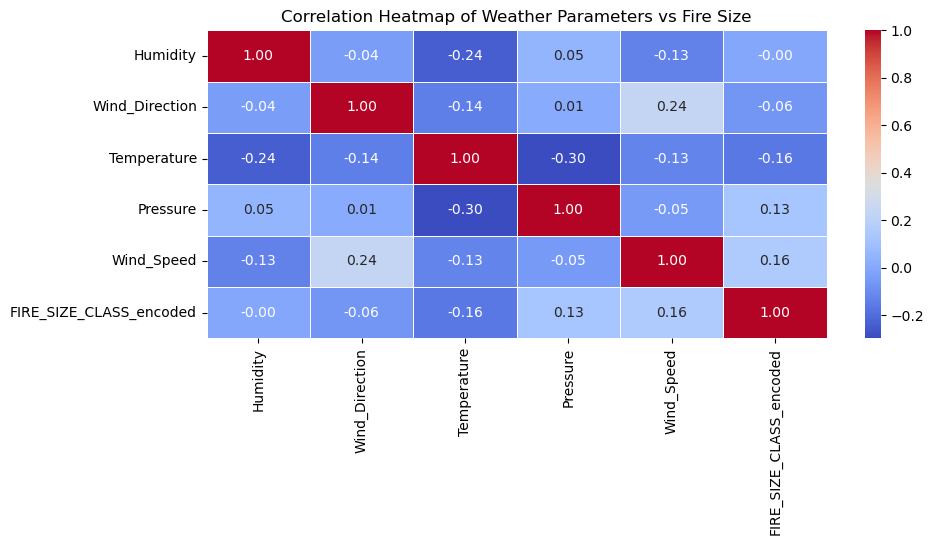

In [90]:
plt.figure(figsize=(10, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Weather Parameters vs Fire Size")
plt.show()

---

### Creating Regression Models

#### Regressing fire size (ordinal) on weather and location features (continuous) using **ordinal logistic regression**

Because fire size is an ordinal categorical variable with 3 different levels, we can run an ordinal logistic regression model (Proportional Odds Model).

In [32]:
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from statsmodels.miscmodels.ordinal_model import OrderedModel
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
X = final_df[['Humidity', 'Wind_Direction', 'Temperature', 'Pressure', 'Wind_Speed', 'City_Lat', 'City_Lon', 'FIRE_SIZE_CLASS_encoded']]
features = X.copy()

# Joining Features with City Latitude and Longitude
final_df[["City_Lat", "City_Lon"]] = final_df[["City_Lat", "City_Lon"]].astype(float)
features = features.drop(columns=['City_Lat', 'City_Lon']).join(final_df[['City_Lat', 'City_Lon']])

# Checking for variable collinearity
vif_data = pd.DataFrame()
vif_data["Variable"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
print(vif_data)

features

                  Variable          VIF
0                 Humidity     8.677323
1           Wind_Direction     4.299452
2              Temperature   974.838476
3                 Pressure  1217.473546
4               Wind_Speed     2.734475
5  FIRE_SIZE_CLASS_encoded     1.976544
6                 City_Lat    88.263816
7                 City_Lon    42.921262


,Humidity,Wind_Direction,Temperature,Pressure,Wind_Speed,FIRE_SIZE_CLASS_encoded,City_Lat,City_Lon
0,84.0,0.0,278.175000,1015.0,0.0,1,44.979969,-93.263840
1,75.0,0.0,278.120000,1015.0,0.0,1,44.979969,-93.263840
2,57.0,0.0,282.480000,1015.0,0.0,1,44.979969,-93.263840
3,53.0,63.0,285.643333,1014.0,1.0,1,44.979969,-93.263840
4,49.0,126.0,288.806667,1014.0,2.0,1,44.979969,-93.263840
...,...,...,...,...,...,...,...,...
1664,93.0,0.0,274.970000,1018.0,0.0,0,42.358429,-71.059769
1665,44.0,277.0,274.350000,1014.0,2.0,0,42.358429,-71.059769
1666,47.0,320.0,273.720000,1018.0,5.0,0,42.358429,-71.059769
1667,48.0,273.0,273.360000,1028.0,0.0,0,42.358429,-71.059769


#### Standardizing Independent Variables that have higher VIFs

Keeping latitude and longitude the same because it only has meaning when kept in original scale

In [34]:
# Define features to standardize and keep unstandardized
standardized_features = ['Humidity', 'Temperature', 'Pressure']
nonstandardized_features = ['Wind_Direction', 'Wind_Speed', 'City_Lat', 'City_Lon']

# Standardize selected features
scaler = StandardScaler()
standardized_array = scaler.fit_transform(final_df[standardized_features])

# Convert scaled features into DataFrame with correct index
standardized_df = pd.DataFrame(standardized_array, columns=[f"{col}_standardized" for col in standardized_features], index=final_df.index)

# Join with unstandardized features
features_scaled = standardized_df.join(final_df[nonstandardized_features])

# Check the final DataFrame
features_scaled.head()

,Humidity_standardized,Temperature_standardized,Pressure_standardized,Wind_Direction,Wind_Speed,City_Lat,City_Lon
0,1.213962,-1.396247,-0.446127,0.0,0.0,44.979969,-93.26384
1,0.819241,-1.402128,-0.446127,0.0,0.0,44.979969,-93.26384
2,0.029799,-0.935967,-0.446127,0.0,0.0,44.979969,-93.26384
3,-0.145632,-0.597751,-0.545924,63.0,1.0,44.979969,-93.26384
4,-0.321064,-0.259535,-0.545924,126.0,2.0,44.979969,-93.26384


In [35]:
# Checking for variable collinearity after scaling
vif_data = pd.DataFrame()
vif_data["Variable"] = features_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(features_scaled.values, i) for i in range(features_scaled.shape[1])]
print(vif_data)

                   Variable        VIF
0     Humidity_standardized   1.185646
1  Temperature_standardized   1.343688
2     Pressure_standardized   1.235355
3            Wind_Direction   4.327758
4                Wind_Speed   2.699734
5                  City_Lat  28.839814
6                  City_Lon  25.808730


Dropping City_Lon from X variables because City Latitude is likely more important to prediction than City Longitude since Latitude is on average associated average location temperature (cities closer to equator have higher temperatures).

In [36]:
# Dropping City_Lon from X variables
features_scaled = features_scaled.drop(columns=['City_Lon'])
print("predictor variables: ")

vif_data = pd.DataFrame()
vif_data["Variable"] = features_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(features_scaled.values, i) for i in range(features_scaled.shape[1])]
print(vif_data)

predictor variables: 
                   Variable       VIF
0     Humidity_standardized  1.157844
1  Temperature_standardized  1.237701
2     Pressure_standardized  1.197985
3            Wind_Direction  4.296774
4                Wind_Speed  2.688141
5                  City_Lat  4.804697


No issues with multicollinearity now!

In [37]:
multinomial_df = features_scaled.join(final_df["FIRE_SIZE_CLASS_encoded"])
multinomial_df

,Humidity_standardized,Temperature_standardized,Pressure_standardized,Wind_Direction,Wind_Speed,City_Lat,FIRE_SIZE_CLASS_encoded
0,1.213962,-1.396247,-0.446127,0.0,0.0,44.979969,1
1,0.819241,-1.402128,-0.446127,0.0,0.0,44.979969,1
2,0.029799,-0.935967,-0.446127,0.0,0.0,44.979969,1
3,-0.145632,-0.597751,-0.545924,63.0,1.0,44.979969,1
4,-0.321064,-0.259535,-0.545924,126.0,2.0,44.979969,1
...,...,...,...,...,...,...,...
1664,1.608682,-1.738918,-0.146736,0.0,0.0,42.358429,0
1665,-0.540353,-1.805207,-0.545924,277.0,2.0,42.358429,0
1666,-0.408779,-1.872565,-0.146736,320.0,5.0,42.358429,0
1667,-0.364922,-1.911055,0.851234,273.0,0.0,42.358429,0


In [38]:
# Ordered Logistic Regression
formula = 'FIRE_SIZE_CLASS_encoded ~ Humidity_standardized + Temperature_standardized + Pressure_standardized + Wind_Direction + Wind_Speed + City_Lat'
model = OrderedModel.from_formula(
    formula,
    data=multinomial_df,
    distr='logit'
)
result = model.fit(method='bfgs', maxiter=1000) #bfgs method uses Gradients to compute Hessian instead of directly computing, which allows for faster convergence

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.776529
         Iterations: 29
         Function evaluations: 35
         Gradient evaluations: 35
                                OrderedModel Results                               
Dep. Variable:     FIRE_SIZE_CLASS_encoded   Log-Likelihood:                -1296.0
Model:                        OrderedModel   AIC:                             2608.
Method:                 Maximum Likelihood   BIC:                             2651.
Date:                     Sat, 15 Mar 2025                                         
Time:                             17:56:56                                         
No. Observations:                     1669                                         
Df Residuals:                         1661                                         
Df Model:                                8                                         
                               coef    std err          z      P>|z|    

##### Coefficient Interpretations:

Variables that significantly affect fire size
- Higher Pressure associated with Larger Fire Size: a one standard deviation increase in pressure increases the log odds of a larger fire size category by 0.6132. (p < 0.001, strongest effect).
- Higher Humidity associated Larger Fire Size: a one standard deviation increase in humidity increases the log odds of being in a larger fire size category by 0.1083 (p = 0.053, weak effect). **Does not make sense**
- Higher Wind Speed associated with Smaller Fire Size: a one standard deviation decrease in wind speed increases the log odds of being in a larger fire size category by 0.1083 (p = 0.007, moderate effect). **Also does not make sense**
- Lower Latitude: A one degree increase in latitude decreases the fire size log-odds by 0.2030

Variables that do not have a strong relationship with fire size at significance level of 0.05
- Temperature
- Wind Direction

#### Lots of coefficients that don't make sense

### Plotting the Data below to see why the coefficients of humidity and temperature are counterintuitive

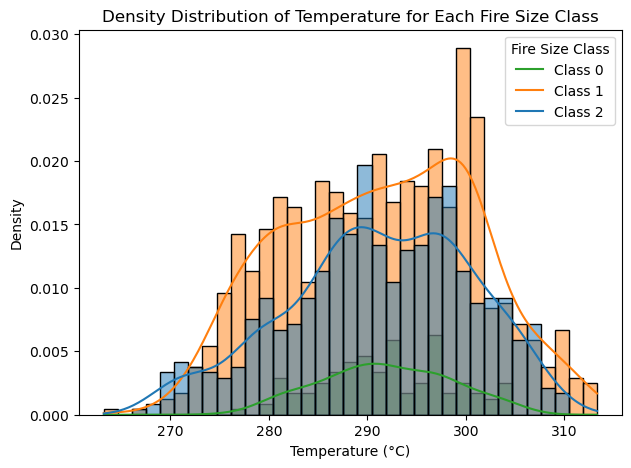

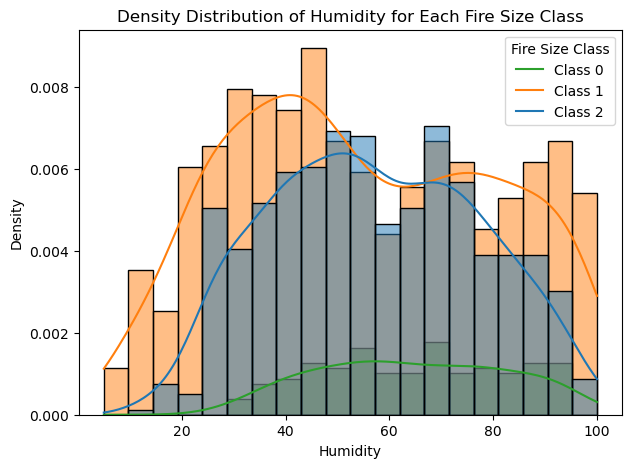

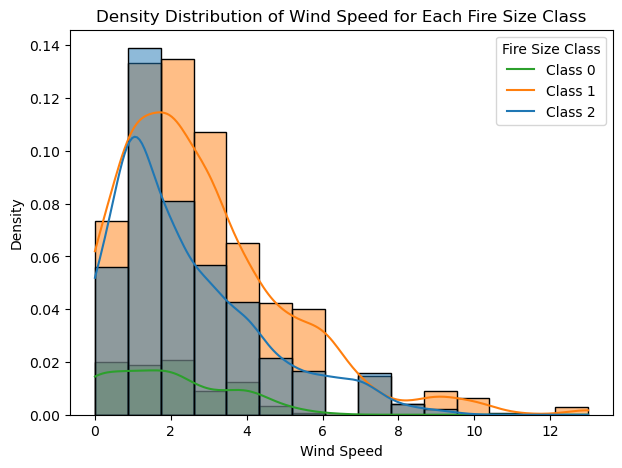

In [39]:
# density plot for temperature distribution by fire size class
plt.figure(figsize=(7, 5))
sns.histplot(
    data=final_df, 
    x="Temperature", 
    hue=final_df["FIRE_SIZE_CLASS_encoded"].astype(str), 
    kde=True, 
    bins=35, 
    stat="density"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Density")
plt.title("Density Distribution of Temperature for Each Fire Size Class")
plt.legend(title="Fire Size Class", labels=["Class 0", "Class 1", "Class 2"])
plt.show()

# density plot for humidity distribution by fire size class
plt.figure(figsize=(7, 5))
sns.histplot(
    data=final_df, 
    x="Humidity", 
    hue=final_df["FIRE_SIZE_CLASS_encoded"].astype(str), 
    kde=True, 
    bins=20, 
    stat="density" 
)

plt.xlabel("Humidity")
plt.ylabel("Density")
plt.title("Density Distribution of Humidity for Each Fire Size Class")
plt.legend(title="Fire Size Class", labels=["Class 0", "Class 1", "Class 2"])
plt.show()

# density plot for wind speed distribution by fire size class
plt.figure(figsize=(7, 5))
sns.histplot(
    data=final_df, 
    x="Wind_Speed", 
    hue=final_df["FIRE_SIZE_CLASS_encoded"].astype(str), 
    kde=True, 
    bins=15, 
    stat="density" 
)

plt.xlabel("Wind Speed")
plt.ylabel("Density")
plt.title("Density Distribution of Wind Speed for Each Fire Size Class")
plt.legend(title="Fire Size Class", labels=["Class 0", "Class 1", "Class 2"])
plt.show()

In [40]:
temp_humidity_df = pd.DataFrame()

for fire_class in [0,1,2]:
    queried_df = final_df[final_df["FIRE_SIZE_CLASS_encoded"] == fire_class]
    avg_class_humidity = sum(queried_df["Humidity"])/len(queried_df["Humidity"])
    avg_class_temp = sum(queried_df["Temperature"])/len(queried_df["Temperature"])
    avg_class_speed = sum(queried_df["Wind_Speed"])/len(queried_df["Wind_Speed"])

    temp_humidity_df.loc[fire_class, "Average Temperature"] = avg_class_temp
    temp_humidity_df.loc[fire_class, "Average Humidity"] = avg_class_humidity
    temp_humidity_df.loc[fire_class, "Average Wind Speed"] = avg_class_speed

temp_humidity_df.index.name = "Fire Size Class"

temp_humidity_df

,Average Temperature,Average Humidity,Average Wind Speed
Fire Size Class,,,
0,291.216881,54.638646,2.775109
1,291.137373,57.166667,2.323810
2,291.857703,64.512195,1.861789


Seems like average humidity increases as class size increases in the data, which doesn't make sense scientifically but matches our model.

---

### Trying interaction terms: 
shows that the effect of temperature on fire size becomes stronger (more positive) as humidity increases which matches what we see happening in the data above.

In [41]:
formula = 'FIRE_SIZE_CLASS_encoded ~ Temperature_standardized * Humidity_standardized + Pressure_standardized + Wind_Direction + Wind_Speed + City_Lat'
model = OrderedModel.from_formula(
    formula,
    data=multinomial_df,
    distr='logit'
)
result = model.fit(method='bfgs', maxiter=1000) #bfgs method uses Gradients to compute Hessian instead of directly computing, which allows for faster convergence

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.757547
         Iterations: 31
         Function evaluations: 37
         Gradient evaluations: 37
                                OrderedModel Results                               
Dep. Variable:     FIRE_SIZE_CLASS_encoded   Log-Likelihood:                -1264.3
Model:                        OrderedModel   AIC:                             2547.
Method:                 Maximum Likelihood   BIC:                             2595.
Date:                     Sat, 15 Mar 2025                                         
Time:                             17:56:57                                         
No. Observations:                     1669                                         
Df Residuals:                         1660                                         
Df Model:                                9                                         
                                                     coef    std err    

### Exploratory Data Analysis 

In [42]:
final_df['FIRE_SIZE_CLASS_encoded'].value_counts()

0    916
1    630
2    123
Name: FIRE_SIZE_CLASS_encoded, dtype: int64

In [43]:
len(final_df['STATE'].value_counts())

21

We were curious to see how the sizes of fires varied across the United States. As you can see above, the 'FIRE_SIZE_CLASS_encoded' column has 3 categories that fires are classified into depending on the size of the fires: 
- 0: (0, 0.25] acres i.e, fires that are greater than 0 but less than or equal to 0.25 acres
- 1: [0.26-9.9] acres  
- 2: [10.0-99.9] acres

We created a choropleth map that shows the average size of the fires per state across the country. There are 21 U.S. states represented in our dataset, and you can see the average fire sizes in those states below. We chose a continuous color scale to emphasize how Florida, for instance, has larger fires on average than Colorado. 

In [44]:
state_fire_classes = final_df.groupby("STATE", as_index=False)["FIRE_SIZE_CLASS_encoded"].mean()

fig = px.choropleth(
        state_fire_classes,
        locations="STATE",
        locationmode="USA-states",
        scope="usa",
        color="FIRE_SIZE_CLASS_encoded",
        color_continuous_scale="Reds",  
        labels={"FIRE_SIZE_CLASS_encoded": "Avg Fire Size Class"},
        title="Wildfire Size Class Across the USA" )

fig.show()

Similar to the U.S. map above, we wanted to create a map that would portray how the fire sizes vary by latitude and longitude. We ensured the color choices for the legend would align with reader expectations, and so we chose yellow, orange and red to portray the increasing fire sizes. 

In [ ]:
cols = ['FIRE_SIZE', 'LONGITUDE', 'LATITUDE', 'FIRE_SIZE_CLASS_encoded']
copy = final_df.copy()
for col in copy.columns: 
    if col not in cols:
        copy.drop(col, axis=1, inplace=True)


In [48]:

size_scale = 10
copy['BUBBLE_SIZE'] = copy['FIRE_SIZE'] / copy['FIRE_SIZE'].max() * size_scale + 10
copy['FIRE_SIZE_CLASS_encoded'] = copy['FIRE_SIZE_CLASS_encoded'].astype(str)
fig = px.scatter(
    copy, 
    x='LONGITUDE', 
    y='LATITUDE', 
    color='FIRE_SIZE_CLASS_encoded',  
     opacity=0.7,
    size=[20] * len(copy), 
    title="Fire Intensity Map", 
    category_orders={"FIRE_SIZE_CLASS_encoded": ["0", "1", "2"]},
    color_discrete_map= {'0': 'yellow', '1': 'orange', '2': 'red'}
)
fig.update_layout(legend_title_text="fire size class")

fig.show()


In [49]:
final_df.columns

Index(['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM',
       'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME',
       'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY',
       'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE',
       'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE',
       'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY',
       'FIPS_CODE', 'FIPS_NAME', 'Shape', 'Fire_Lat', 'Fire_Lon', 'City',
       'City_Lat', 'City_Lon', 'Distance_Miles', 'discovery_date', 'Datetime',
       'City', 'Humidity', 'Wind_Direction', 'Temperature', 'Pressure',
       'Wind_Speed', 'FIRE_SIZE_CLASS_encoded'],
      dtype='object')

<Figure size 800x200 with 0 Axes>

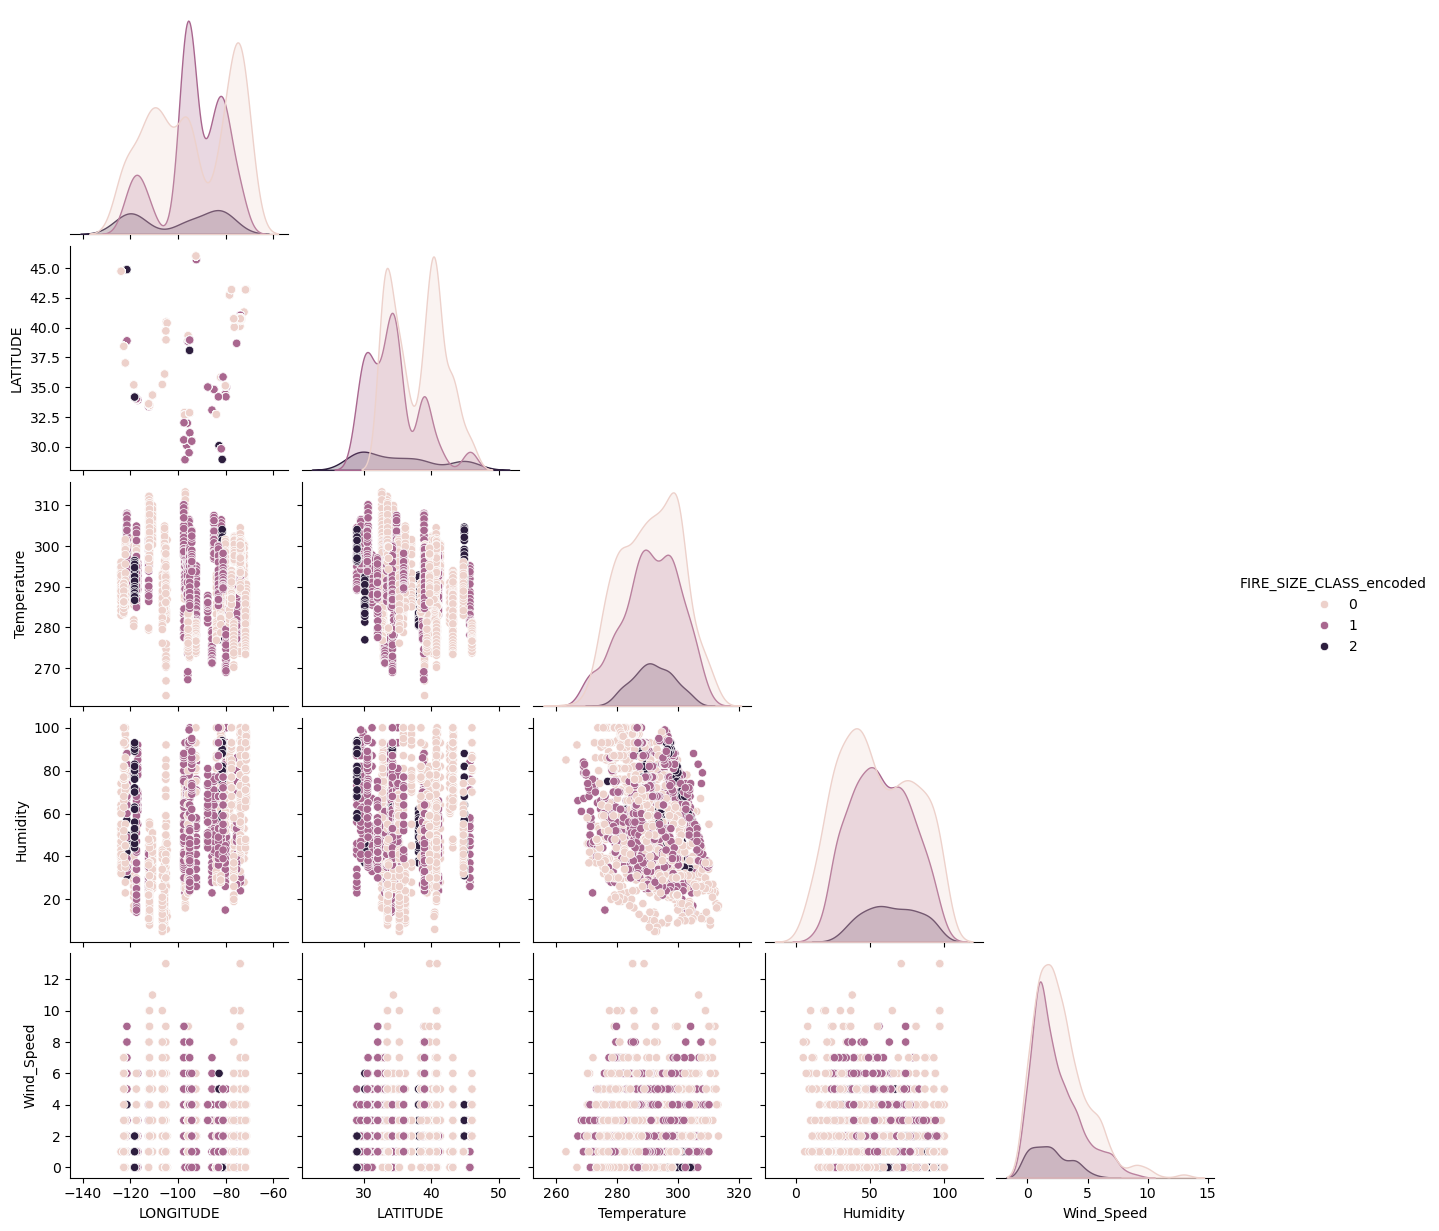

In [50]:
copy = final_df[["FIRE_SIZE_CLASS_encoded", "LONGITUDE", "LATITUDE", "Temperature", "Humidity", "Wind_Speed"]]
plt.figure(figsize=(8, 2))
sns.pairplot(copy, hue="FIRE_SIZE_CLASS_encoded", diag_kind="kde", corner=True)
plt.show()

In [51]:
missing_values = final_df.isnull().sum()
missing_percentage = (final_df.isnull().sum() / len(final_df)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)
print(missing_df)
#print(missing_df.dtypes)

                         Missing Values  Percentage (%)
ICS_209_INCIDENT_NUMBER            1669      100.000000
ICS_209_NAME                       1669      100.000000
MTBS_ID                            1669      100.000000
MTBS_FIRE_NAME                     1669      100.000000
COMPLEX_NAME                       1669      100.000000
FIRE_CODE                          1524       91.312163
LOCAL_FIRE_REPORT_ID               1475       88.376273
CONT_TIME                           499       29.898143
DISCOVERY_TIME                      372       22.288796
FIRE_NAME                           350       20.970641
CONT_DATE                           350       20.970641
CONT_DOY                            350       20.970641
COUNTY                              219       13.121630
FIPS_CODE                           219       13.121630
FIPS_NAME                           219       13.121630
LOCAL_INCIDENT_ID                    72        4.313960


In [52]:
#confirming that no missing values are present in the numeric columns

numeric_cols = pd.DataFrame(final_df.select_dtypes(include=[np.number]).columns)
missing_values = numeric_cols.isnull().sum()
missing_percentage = (numeric_cols.isnull().sum() / len(numeric_cols)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)
missing_df

,Missing Values,Percentage (%)


City_Lat           0
City_Lon           0
Humidity           0
Wind_Direction     0
Temperature        0
Pressure          22
Wind_Speed        30
dtype: int64


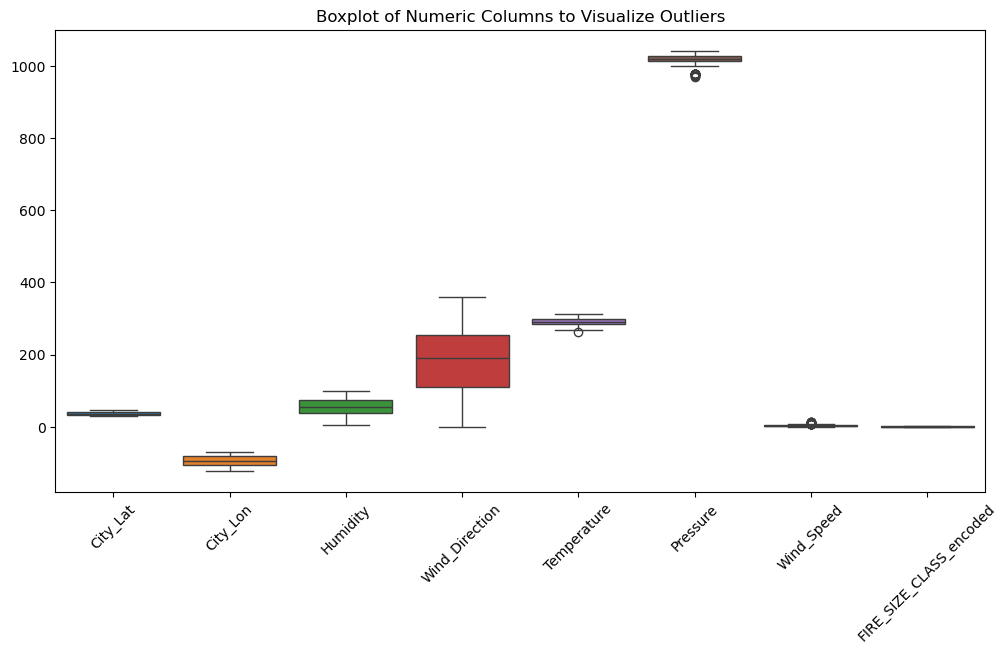

In [53]:
from scipy.stats import zscore

numeric_cols = final_df.select_dtypes(include=[np.number]).columns
z_scores = np.abs(final_df[numeric_cols].apply(zscore))

outlier_counts = (z_scores > 3).sum()
outlier_counts.drop('FIRE_SIZE_CLASS_encoded', inplace=True)
print(outlier_counts)
plt.figure(figsize=(12, 6))
sns.boxplot(data=final_df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Columns to Visualize Outliers")
plt.show()


## next we use other prediction methods (Yiming 0315)

In [56]:
final_df.columns

Index(['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM',
       'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME',
       'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY',
       'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE',
       'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE',
       'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY',
       'FIPS_CODE', 'FIPS_NAME', 'Shape', 'Fire_Lat', 'Fire_Lon', 'City',
       'City_Lat', 'City_Lon', 'Distance_Miles', 'discovery_date', 'Datetime',
       'City', 'Humidity', 'Wind_Direction', 'Temperature', 'Pressure',
       'Wind_Speed', 'FIRE_SIZE_CLASS_encoded'],
      dtype='object')

### choosing some columns for prediction

In [91]:
prediction_df = final_df[["Fire_Lat","Fire_Lon","Datetime",'Humidity', 'Wind_Direction', 'Temperature', 'Pressure',
       'Wind_Speed', 'FIRE_SIZE_CLASS_encoded']]
prediction_df

,Fire_Lat,Fire_Lon,Datetime,Humidity,Wind_Direction,Temperature,Pressure,Wind_Speed,FIRE_SIZE_CLASS_encoded
0,33.077967,-116.79815,2014-01-08 12:00:00,54.0,296.0,281.58,1028.0,1.0,1
1,33.077967,-116.79815,2014-01-08 13:00:00,54.0,36.0,281.06,1028.0,0.0,1
2,33.077967,-116.79815,2014-01-08 14:00:00,54.0,67.0,281.03,1028.0,0.0,1
3,33.077967,-116.79815,2014-01-08 15:00:00,54.0,296.0,280.50,1028.0,1.0,1
4,33.077967,-116.79815,2014-01-08 16:00:00,54.0,32.0,281.45,1029.0,0.0,1
...,...,...,...,...,...,...,...,...,...
2079,41.125,-73.7,2014-07-16 08:00:00,94.0,220.0,295.36,1007.0,2.0,0
2080,41.125,-73.7,2014-07-16 09:00:00,94.0,210.0,294.95,1007.0,2.0,0
2081,41.125,-73.7,2014-07-16 10:00:00,88.0,220.0,294.55,1008.0,3.0,0
2082,41.125,-73.7,2014-07-16 11:00:00,88.0,320.0,293.94,1008.0,4.0,0


In [120]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = prediction_df.copy()
df["Datetime"] = pd.to_datetime(df["Datetime"])
df["hour"] = df["Datetime"].dt.hour
df["month"] = df["Datetime"].dt.month
df["is_daytime"] = df["hour"].between(6, 18).astype(int)

df = df.drop(columns=["Datetime"]) 

X = df.drop(columns="FIRE_SIZE_CLASS_encoded")
y = df["FIRE_SIZE_CLASS_encoded"]

numeric_features = ["Humidity", "Temperature", "Pressure", "Wind_Speed"]
cyclical_features = ["hour", "Wind_Direction"]

# Cyclical encoding for hour and wind direction
def cyclical_encoding(X, col, max_val):
    return np.sin(2 * np.pi * X[col].to_numpy() / max_val).reshape(-1, 1)  # Convert to NumPy array and reshape

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cyclical_hour", FunctionTransformer(lambda x: cyclical_encoding(x, "hour", 24)), ["hour"]),
        ("cyclical_wind", FunctionTransformer(lambda x: cyclical_encoding(x, "Wind_Direction", 360)), ["Wind_Direction"])
    ]
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)


In [121]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced"))
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Humidity', 'Temperature',
                                                   'Pressure', 'Wind_Speed']),
                                                 ('cyclical_hour',
                                                  FunctionTransformer(func=<function <lambda> at 0x3493e3c40>),
                                                  ['hour']),
                                                 ('cyclical_wind',
                                                  FunctionTransformer(func=<function <lambda> at 0x3493e18a0>),
                                                  ['Wind_Direction'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced'))])

### using standard 80%-20% train test split, we achieve 88% prediction accuracy using random forest model

In [122]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8800959232613909


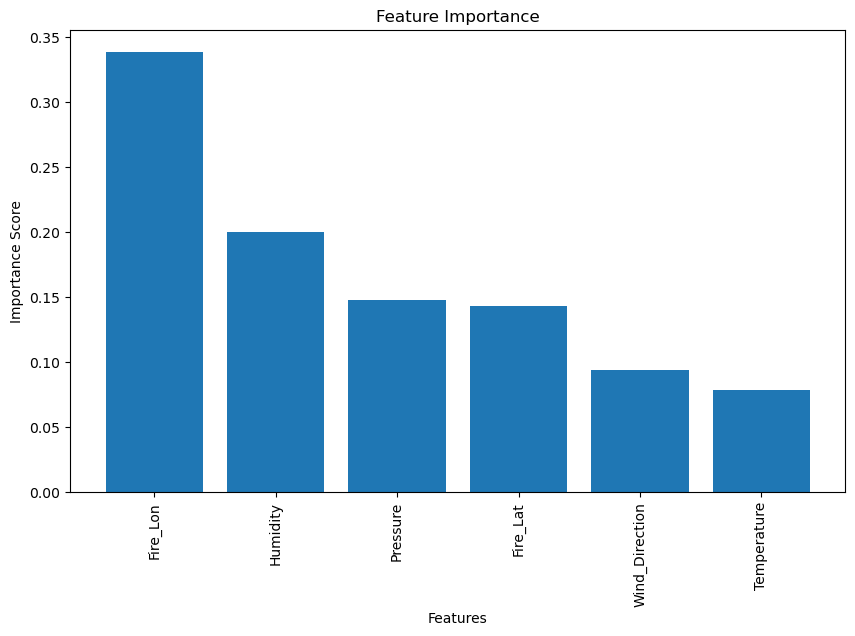

In [123]:
importances = model.named_steps["classifier"].feature_importances_
feature_names = X_train.columns

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()


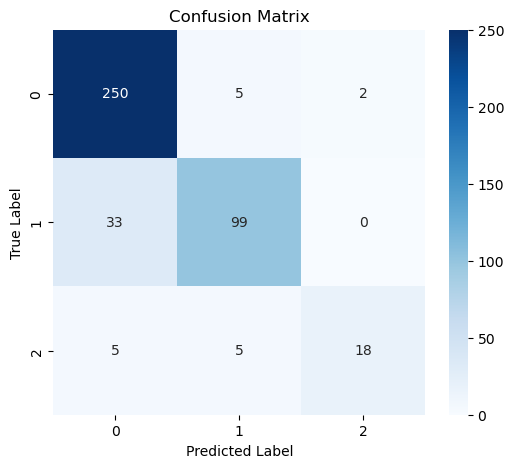

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["0", "1","2"], yticklabels=["0", "1","2"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


### now we build a neural network model

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

df = prediction_df.copy()
df["Datetime"] = pd.to_datetime(df["Datetime"])
df["hour"] = df["Datetime"].dt.hour
df["month"] = df["Datetime"].dt.month
df["is_daytime"] = df["hour"].between(6, 18).astype(int)

df = df.drop(columns=["Datetime"])
X = df.drop(columns="FIRE_SIZE_CLASS_encoded")
y = df["FIRE_SIZE_CLASS_encoded"].values
numeric_features = ["Humidity", "Temperature", "Pressure", "Wind_Speed"]

def cyclical_encoding(X, col, max_val):
    return np.sin(2 * np.pi * X[col].to_numpy() / max_val).reshape(-1, 1)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cyclical_hour", FunctionTransformer(lambda x: cyclical_encoding(x, "hour", 24)), ["hour"]),
        ("cyclical_wind", FunctionTransformer(lambda x: cyclical_encoding(x, "Wind_Direction", 360)), ["Wind_Direction"])
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [ ]:
class FireSizeClassifier(nn.Module):
    def __init__(self, input_dim, n_classes):
        super(FireSizeClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.6),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, n_classes)
        )
    
    def forward(self, x):
        return self.model(x)

In [ ]:
# Initialize model
input_dim = X_train_transformed.shape[1]
n_classes = len(np.unique(y))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FireSizeClassifier(input_dim, n_classes).to(device)

# Class weights
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Loss, optimizer, and scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
early_stopping_patience = 15
best_val_loss = float("inf")
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(200):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_fire_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered")
            break

model.load_state_dict(torch.load("best_fire_model.pth"))

Epoch 10: Train Loss = 0.6516, Val Loss = 0.5387
Epoch 20: Train Loss = 0.5193, Val Loss = 0.5070
Epoch 30: Train Loss = 0.5488, Val Loss = 0.5326
Epoch 40: Train Loss = 0.4965, Val Loss = 0.4818
Epoch 50: Train Loss = 0.4347, Val Loss = 0.5162
Epoch 60: Train Loss = 0.4493, Val Loss = 0.5102
Epoch 70: Train Loss = 0.4221, Val Loss = 0.5138
Early stopping triggered


<All keys matched successfully>

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.7578


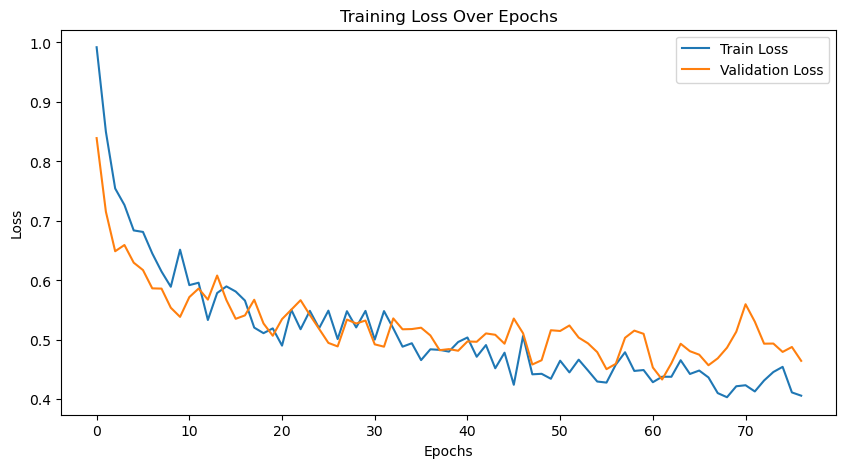

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss Over Epochs")
plt.show()

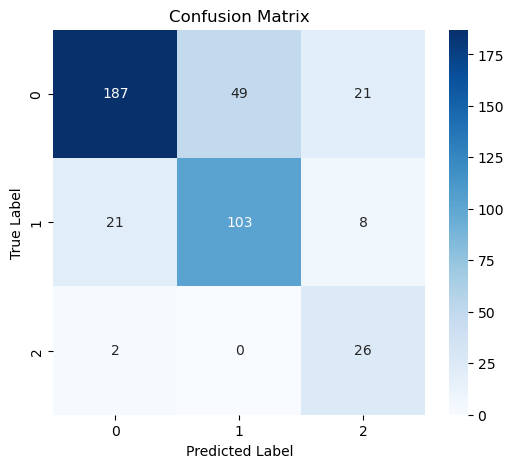

In [ ]:
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1) 
        y_true.extend(y_batch.cpu().numpy())  
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["0", "1", "2"], yticklabels=["0", "1", "2"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## some conclusion: the prediction looks more reasonable in random forest, and we can see the feature importance score is working. However, neural network is not as effective as expected. It might work better with more data